# SST for ICESat-2 transects

In [1]:
# Import libraries and modules
%config InlineBackend.figure_format = 'svg'
%matplotlib widget
import pandas as pd
import xarray as xr
import geopandas as gpd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pylab as plt
from matplotlib import colors
from matplotlib.pylab import rcParams
import cartopy.crs as ccrs
import cartopy

import os
from cycler import cycler
import pyproj
from pyproj import Proj, transform
import gc
from pathlib import Path

import earthaccess

import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np                   # Numeric Python
import matplotlib.pyplot as plt      # Plotting routines
import h5py                          # general HDF5 reading/writing library
import rioxarray as rx               # Package to read raster data from hdf5 files
from pyproj import Transformer, CRS  # libraries to allow coordinate transforms
import glob                          # Package to locate files on disk
import os                            # File-level utilities
import re                            # regular expressions for string interpretation
import xarray as xr
from tqdm import tqdm
from scipy.stats import norm
import pickle

In [3]:
import pystac_client
import geopandas as gpd
import ast
import pandas as pd
import geoviews as gv
import hvplot.pandas
from ipywidgets import interact
from IPython.display import display, Image
import intake # if you've installed intake-STAC, it will automatically import alongside intake
import boto3
import rasterio as rio
import rioxarray as rxr
from rasterio.session import AWSSession
from rasterio.plot import show
from dask.utils import SerializableLock
import hvplot.xarray
from pyproj import Proj,transform,Transformer

In [4]:
#For color cycling in plots that is color blind friendly...make new ones at "I want hue" tools.medialab.sciences-po.fr/iwanthue
color_cycler = cycler(color=["#6777cf","#adba49","#c65ca0","#5fa042","#683287","#72ce7b","#c44a48","#45c7a9","#933c1d","#d0803f","#ac9239","#317c39"])
colorline_cycler = (cycler(color=["#75a141","#6c61b9","#bc4d45","#c1913d","#b85298","#4aa8e8"]) +
                 cycler(linestyle=['-','--',':','-.','-','--']))
rcParams['axes.prop_cycle'] = cycler('color', color_cycler)

In [5]:
# Coefficients for calibration
calib_m = 0.76 
calib_b = 0.55

In [6]:
# Set paths and important variables
basepath = Path('/home/jovyan/Landsat_SST_algorithm')
sstpath = basepath / 'Data/SST/UncalibratedSST/PineIslandPlume/'
lstpath = basepath / 'Data/SST/LST/'
figpath = basepath / 'Figures/'
is2path = basepath / 'Data/'

In [7]:
# Bounding box
# bbox = (-101.98,-75.09,-101.65,-75.05) # PIG west plume based on Nov 06, 2014 Worldview image?
bbox = (-101.8,-75.23,-100.50,-74.80) # PIG 2019?
# bbox = (-105.0, -74.970, -105.08, -74.950) #(west, south, east, north)
spatial_extent = [-101.8,-75.23,-100.50,-74.80]

In [8]:
ds19 = xr.open_dataset('/home/jovyan/Data/2019IS2trans.nc')
ds21 = xr.open_dataset('/home/jovyan/Data/2021IS2trans.nc')

## SST timeseries across the IS2 transects

In [9]:
# Authenticate for accessing NASA data (MODIS)
auth = earthaccess.login(strategy="netrc")
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

In [10]:
def subset_img(da,polarx,polary):
    '''
    Subset image in xarray to desired coordinates. Because Landsat polar stereo projection can be oriented
    in many different directions, when coordinates to subset an image are reprojected from lat/lon they may get 
    flipped for which is larger in the pair. This function checks to make sure we are getting a proper subset and 
    avoids 0 pixels on the x or y axis. 
    
    Note: Input shape dimensions and dataarray v. dataset changes things so input needs to be a dataarray w 
          2 dimensions (x,y)
    
    Input:
    da = xarray DataArray to be subset
    polarx = x coordinates to subset by in polar stereographic projection
    polary = y coordinates to subset by in polar stereographic projection
    
    Output:
    ls_sub = subset xarray DataArray
    
    '''
    # ***Landsat shape dimensions are one fewer than they are for LandsatCalibration [0,1] not [1,2], no .to_array() or Band
    ls_sub = da.sel(y=slice(polary[1],polary[0]),x=slice(polarx[0],polarx[1]))

    # Check for right dimensions because y order changes sometimes
    if (ls_sub.x.shape[0]==0) & (ls_sub.y.shape[0]==0):
        print ('L8 x and y shapes are 0')
        ls_sub = da.sel(y=slice(polary[0],polary[1]),x=slice(polarx[1],polarx[0]))
    elif ls_sub.y.shape[0]==0:
        print ('L8 y shape is 0')
        ls_sub = da.sel(y=slice(polary[0],polary[1]),x=slice(polarx[0],polarx[1]))
    elif ls_sub.x.shape[0]==0:
        print ('L8 x shape is 0')
        ls_sub = da.sel(y=slice(polary[1],polary[0]),x=slice(polarx[1],polarx[0]))
    print(ls_sub.shape)
    
    return ls_sub

##########################

# Preprocess to add time dimension and the file name to open_mfdataset for landsat using the filename
def add_time_dim(ds):
    lstr = ds.encoding["source"].split("LC0",1)[1]
    times = pd.to_datetime(lstr[14:22], format='%Y%m%d')
    idee = ds.encoding["source"].split("/")[8][:-4]
    return ds.assign_coords(time=times,ID=idee)

def add_time_dim_LST(ds):
    lstr = ds.encoding["source"].split("LC0",1)[1]
    times = pd.to_datetime(lstr[14:22], format='%Y%m%d')
    idee = ds.encoding["source"].split("/")[7][:-4]
    return ds.assign_coords(time=times,ID=idee)

In [11]:
def getclosest_ij(lons,lats,lonpt,latpt):
    '''
    Determine pixel index of the closest grid cell to a desired point.
    
    Input:
    lons/lats: 2D array of lons/lats
    lonpt/latpt: lon/lat of point to find an index for closest grid cell
    Return:
    x/y: index of lon/lat
    '''
    
    abslat=np.abs(lats-latpt)
    abslon=np.abs(lons-lonpt)
    c = np.maximum(abslon,abslat)
    x, y = np.where(c == np.min(c))
    return x,y

def extract_line(data,lons,lats,lonpt,latpt):
    '''
    Extract a line of pixels between the max and min of another set of lat/lon data
    '''
    
    max_idx = getclosest_ij(lons,lats,lonpt.max().values,latpt.max().values)
    min_idx = getclosest_ij(lons,lats,lonpt.min().values,latpt.min().values)
    x0, y0 = min_idx # These are in _pixel_ coordinates!!
    x1, y1 = max_idx
    num = max(np.abs(x1-x0)[0],np.abs(y1-y0)[0])
    x, y = np.linspace(x0, x1, num), np.linspace(y0, y1, num)

    # Extract the values along the line
    data_transect = data[x.astype(int), y.astype(int)]
    return data_transect

def get_transect_v2(timagen,timage,pol_lon,pol_lat,dataset):
    t_transect = extract_line(timagen,pol_lon,pol_lat,dataset.longitude,dataset.latitude)
    # mask_transect = extract_line(timage.mask.values,pol_lon,pol_lat,dataset.longitude,dataset.latitude)
    lat_transect = extract_line(pol_lat,pol_lon,pol_lat,dataset.longitude,dataset.latitude)
    lon_transect = extract_line(pol_lon,pol_lon,pol_lat,dataset.longitude,dataset.latitude)
    return t_transect,lat_transect,lon_transect #mask_transect,

In [12]:
# Get Landsat file paths in directory
lsatfiles = os.listdir(sstpath)
SSTfiles = [x for x in lsatfiles if (x[-3:] == 'tif') & ((x[17:21] == '2021')|(x[17:21] == '2022')|(x[17:21] == '2023'))]
SSTfiles = sorted(SSTfiles, key=lambda x: x.split('_')[4])

In [13]:
SSTfiles

['LC08_L1GT_231114_20221203_20221212_02_T2_143415_Cel.tif',
 'LC08_L1GT_160130_20221202_20221212_02_T2_072152_Cel.tif',
 'LC08_L1GT_233114_20221201_20221212_02_T2_144637_Cel.tif',
 'LC08_L1GT_233113_20221201_20221212_02_T2_144613_Cel.tif',
 'LC08_L1GT_158131_20221220_20221227_02_T2_070945_Cel.tif',
 'LC08_L1GT_001113_20221224_20230103_02_T2_145213_Cel.tif',
 'LC08_L1GT_231114_20230104_20230111_02_T2_143406_Cel.tif',
 'LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif',
 'LC08_L1GT_232113_20221226_20230113_02_T2_143952_Cel.tif',
 'LC08_L1GT_156131_20221222_20230113_02_T2_065721_Cel.tif',
 'LC08_L1GT_160130_20221218_20230113_02_T2_072144_Cel.tif',
 'LC08_L1GT_158131_20221204_20230113_02_T2_070954_Cel.tif',
 'LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif',
 'LC08_L1GT_003113_20230123_20230207_02_T2_150433_Cel.tif',
 'LC08_L1GT_001113_20230125_20230208_02_T2_145212_Cel.tif',
 'LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif',
 'LC08_L1GT_232114_20230212_20230218_02_

In [14]:
#2019
allfiles = ['LC08_L1GT_233113_20221201_20221212_02_T2_144613_Cel.tif',
            # 'LC08_L1GT_160130_20221202_20221212_02_T2_072152_Cel.tif', #
            # 'LC08_L1GT_158131_20221204_20230113_02_T2_070954_Cel.tif', #
            # 'LC08_L1GT_158130_20221220_20221227_02_T2_070921_Cel.tif', #
            'LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif',
            'LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif',
            'LC08_L1GT_001113_20230125_20230208_02_T2_145212_Cel.tif',
            'LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif',
            # 'LC08_L1GT_233113_20230219_20230224_02_T2_144550_Cel.tif',
            'LC08_L1GT_232113_20230228_20230315_02_T2_143932_Cel.tif',
            'LC08_L1GT_003113_20230312_20230321_02_T2_150410_Cel.tif'
           ]

beforefiles = ['LC08_L1GT_233113_20221201_20221212_02_T2_144613_Cel.tif',
            # 'LC08_L1GT_160130_20221202_20221212_02_T2_072152_Cel.tif', # 
            # 'LC08_L1GT_158131_20221204_20230113_02_T2_070954_Cel.tif', #
            'LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif',
            'LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif',
            'LC08_L1GT_001113_20230125_20230208_02_T2_145212_Cel.tif',
           ]
afterfiles = ['LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif',
            'LC08_L1GT_233113_20230219_20230224_02_T2_144550_Cel.tif',
            'LC08_L1GT_232113_20230228_20230315_02_T2_143932_Cel.tif',
            'LC08_L1GT_003113_20230312_20230321_02_T2_150410_Cel.tif'
           ]

# SSTfiles = ['LC08_L1GT_003113_20230312_20230321_02_T2_150410_Cel.tif',
# 'LC08_L1GT_232113_20230228_20230315_02_T2_143932_Cel.tif',
# 'LC08_L1GT_233113_20230219_20230224_02_T2_144550_Cel.tif',
# 'LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif',
# 'LC08_L1GT_001113_20230125_20230208_02_T2_145212_Cel.tif',
# 'LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif',
# 'LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif',
# 'LC08_L1GT_158131_20221204_20230113_02_T2_070954_Cel.tif',
# 'LC08_L1GT_160130_20221202_20221212_02_T2_072152_Cel.tif',
# 'LC08_L1GT_233113_20221201_20221212_02_T2_144613_Cel.tif'
# ]
zorder = [11,10,9,8,7,6,5,4,3,2]

In [15]:
# Convert bounding box to polar for checking if landsat has any data in bounding box
# Speeds up process a lot
source_crs = 'epsg:4326' 
target_crs = 'epsg:3031' # Coordinate system of the file

topolar = pyproj.Transformer.from_crs(source_crs,target_crs)
polarx,polary = topolar.transform([bbox[3],bbox[1]],[bbox[0],bbox[2]]) #LRX,LRY with ULX,ULY

(1521, 1314)
LC08_L1GT_233113_20221201_20221212_02_T2_144613_Cel.tif 2
(1521, 1314)
LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif 2
LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif 4
LC08_L1GT_232114_20221226_20230113_02_T2_144016_Cel.tif 6
(1521, 1314)
LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif 2
LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif 4
LC08_L1GT_160130_20230119_20230131_02_T2_072136_Cel.tif 6
(1521, 1314)
LC08_L1GT_001113_20230125_20230208_02_T2_145212_Cel.tif 2
LC08_L1GT_001113_20230125_20230208_02_T2_145212_Cel.tif 4
(1521, 1314)
LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif 2
LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif 4
LC08_L1GT_002113_20230201_20230209_02_T2_145824_Cel.tif 6
(1521, 1314)
LC08_L1GT_232113_20230228_20230315_02_T2_143932_Cel.tif 2
LC08_L1GT_232113_20230228_20230315_02_T2_143932_Cel.tif 4
LC08_L1GT_232113_20230228_20230315_02_T2_143932_Cel.tif 6
(1521, 1314)
LC08_L1GT_003113_20230312_20230321_02_T

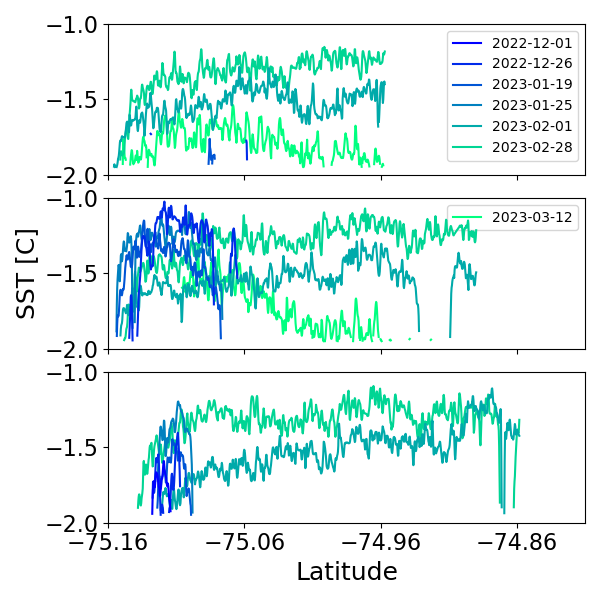

In [17]:
%%time

# Prints out all figures with no transparency per transect

# SSTfiles = allfiles[4:] # Use i += this number to start part way through timeseries and to get the colors right
SSTfiles = allfiles

sst = []
hxlim = [-75.16,-74.81]
thermylim = [-2.0,-1.0]

# Get the winter colormap, Extract the desired number of colors
cmap = plt.cm.winter
num_files = len(allfiles)
colors = cmap(np.linspace(0, 1, num_files))
ds = ds19

fig, axs = plt.subplots(ncols=1,nrows=3,sharey=True,sharex=True,figsize=(6,6))

transects = []
for i,SSTfile in enumerate(SSTfiles):
    try:
        # i+=4
        # Open SST and LST datasets and assign time and ID attributes
        sst_scene = xr.open_dataset(sstpath / SSTfile,chunks=dict(x=512, y=512),engine='rasterio')
        times = pd.to_datetime(SSTfile[17:25], format='%Y%m%d')
        sst_scene = sst_scene.assign_coords(time=times,ID=SSTfile)
        sst_scene = sst_scene.rio.write_crs("epsg:3031", inplace=True)
        SID = sst_scene.ID.values
    
        # Subset, QA and match LST pixels to SST
        sst_scene_sub = subset_img(sst_scene['band_data'].sel(band=1),polarx,polary)
        
        # Cross-calibrate to get absolute temps if needed
        sst_scene_sub = sst_scene_sub * calib_m + calib_b
    
        # QA - remove any pixels cooler than 1.9 because likely ice or cloud contaminated
        sst_scene_sub = sst_scene_sub.where(sst_scene_sub>-1.95)
        pol_y = sst_scene_sub.y
        pol_x = sst_scene_sub.x
        pol_x, pol_y = np.meshgrid(pol_x, pol_y)
    
        inProj = Proj(init='epsg:3031')
        outProj = Proj(init='epsg:4326')
        pol_lon,pol_lat = transform(inProj,outProj,pol_x,pol_y)
        
        timagen = np.array(sst_scene_sub.where(sst_scene_sub.notnull(),np.nan))
    
        # Take transect of pixels used in the calculation
        data = ds.where((ds.spot==1.0), drop=True)
        t_transect,lat_transect,lon_transect = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==2.0), drop=True)
        t_transect2,lat_transect2,lon_transect2 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==3.0), drop=True)
        t_transect3,lat_transect3,lon_transect3 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==4.0), drop=True)
        t_transect4,lat_transect4,lon_transect4 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==5.0), drop=True)
        t_transect5,lat_transect5,lon_transect5 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==6.0), drop=True)
        t_transect6,lat_transect6,lon_transect6 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        
        transects.append([times,t_transect,t_transect2,t_transect3,t_transect4,t_transect5,t_transect6])
    
        # try:
        #     del sst_scene, sst_scene_sub
        # except:
        #     pass
    
        # gc.collect()
        
        # Add to plot
        ax = axs[2]
        ax.tick_params(labelsize=16)
        # if np.isnan(np.nanmax(t_transect))==0:
        #     ax.plot(lat_transect,t_transect,color=colors[i],linestyle=':',zorder=zorder[i])
        #     print(SID,1)
        if np.isnan(np.nanmax(t_transect2))==0:
            ax.plot(lat_transect2,t_transect2,color=colors[i],zorder=zorder[i])
            print(SID,2)
        # if i == 0:
            # ax.plot([-75,-75],[0,0],linestyle='-',color='k',label='l') #SR
            # ax.plot([-75,-75],[0,0],linestyle=':',color='k',label='r') #SR
            # ax.legend(loc='lower right',fontsize=10)
        ax.set_xlim(hxlim);
        ax.set_xticks(np.arange(hxlim[0],hxlim[1],0.1))
        ax.set_ylim(thermylim);
        ax.set_xlabel('Latitude',fontsize=18)  
        
        ax = axs[1]
        ax.tick_params(labelsize=16)
        # if np.isnan(np.nanmax(t_transect3))==0:
        #     ax.plot(lat_transect3,t_transect3,color=colors[i],linestyle=':',zorder=zorder[i])#label='Thermal')
        #     print(SID,3)
        if np.isnan(np.nanmax(t_transect4))==0:
            ax.plot(lat_transect4,t_transect4,color=colors[i],zorder=zorder[i])
            print(SID,4)
        if i > 5:
            ax.plot([-75,-75],[0,0],linestyle='-',color=colors[i],label=f'{times.date()}')
        # ax.set_xlim(sxlim[z]);
        # ax.set_xticks(np.arange(sxlim[z][0],sxlim[z][1],0.05))
        ax.set_ylim(thermylim);
        ax.legend(loc='upper right',fontsize=10) 
        ax.set_ylabel('SST [C]',fontsize=18)
        
        ax = axs[0]
        ax.tick_params(labelsize=16)
        # if np.isnan(np.nanmax(t_transect5))==0:
        #     ax.plot(lat_transect5,t_transect5,color=colors[i],linestyle=':',zorder=zorder[i])
        #     print(SID,5)
        if np.isnan(np.nanmax(t_transect6))==0:
            ax.plot(lat_transect6,t_transect6,color=colors[i],zorder=zorder[i])
            print(SID,6)
        if i < 6:
            ax.plot([-75,-75],[0,0],linestyle='-',color=colors[i],label=f'{times.date()}')
        ax.set_ylim(thermylim);
        ax.legend(loc='upper right',fontsize=10)  

        plt.tight_layout(h_pad=0.02)
        frame_path = f"/home/jovyan/Landsat_SST_algorithm/Figures/SST_frame_{i:03d}.png"
        plt.savefig(frame_path, dpi=200)  # PNG preferred over JPG for lossless GIFs
        # plt.show()
    except:
        print(SSTfile)

In [18]:
%%time

# Prints figures with transparency on previous timeseries

# SSTfiles = SSTfiles[7:]
SSTfiles = allfiles

sst = []
hxlim = [-75.16,-74.81]
thermylim = [-2.0,-1.0]

# Get the winter colormap, Extract the desired number of colors
cmap = plt.cm.winter
num_files = len(allfiles)
colors = cmap(np.linspace(0, 1, num_files))
ds = ds19

alpha_old = 0.5    # transparency for past transects
alpha_new = 1.0    # solid for the current one

# store transects for transparency layering
transects1 = []
transects2 = []
transects3 = []
transects4 = []
transects5 = []
transects6 = []

for i,SSTfile in enumerate(SSTfiles):
    try:
        fig, axs = plt.subplots(ncols=1,nrows=3,sharey=True,sharex=True,figsize=(6,6))
        
        sst_scene = xr.open_dataset(sstpath / SSTfile,chunks=dict(x=512, y=512),engine='rasterio')
        times = pd.to_datetime(SSTfile[17:25], format='%Y%m%d')
        sst_scene = sst_scene.assign_coords(time=times,ID=SSTfile)
        sst_scene = sst_scene.rio.write_crs("epsg:3031", inplace=True)
        SID = sst_scene.ID.values

        sst_scene_sub = subset_img(sst_scene['band_data'].sel(band=1),polarx,polary)
        sst_scene_sub = sst_scene_sub * calib_m + calib_b
        sst_scene_sub = sst_scene_sub.where(sst_scene_sub>-1.95)
        pol_y = sst_scene_sub.y
        pol_x = sst_scene_sub.x
        pol_x, pol_y = np.meshgrid(pol_x, pol_y)

        inProj = Proj(init='epsg:3031')
        outProj = Proj(init='epsg:4326')
        pol_lon,pol_lat = transform(inProj,outProj,pol_x,pol_y)

        timagen = np.array(sst_scene_sub.where(sst_scene_sub.notnull(),np.nan))

        data = ds.where((ds.spot==1.0), drop=True)
        t1,lat1,lon1 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==2.0), drop=True)
        t2,lat2,lon2 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==3.0), drop=True)
        t3,lat3,lon3 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==4.0), drop=True)
        t4,lat4,lon4 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==5.0), drop=True)
        t5,lat5,lon5 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)
        data = ds.where((ds.spot==6.0), drop=True)
        t6,lat6,lon6 = get_transect_v2(timagen,sst_scene_sub,pol_lon,pol_lat,data)

        transects1.append((lat1, t1))
        transects2.append((lat2, t2))
        transects3.append((lat3, t3))
        transects4.append((lat4, t4))
        transects5.append((lat5, t5))
        transects6.append((lat6, t6))

        ax = axs[2]
        ax.tick_params(labelsize=16)
        for j in range(i):
            # ax.plot(transects1[j][0], transects1[j][1], color=colors[j], linestyle=':', alpha=alpha_old)
            ax.plot(transects2[j][0], transects2[j][1], color=colors[j], alpha=alpha_old)
        # if np.isnan(np.nanmax(t1))==0:
        #     ax.plot(lat1, t1, color=colors[i], linestyle=':', alpha=alpha_new)
        if np.isnan(np.nanmax(t2))==0:
            ax.plot(lat2, t2, color=colors[i], alpha=alpha_new)
        # if i == 0:
        #     ax.plot([-75,-75],[0,0],linestyle='-',color='k',label='l')
        #     ax.plot([-75,-75],[0,0],linestyle=':',color='k',label='r')
        ax.set_xlim(hxlim);
        ax.set_xticks(np.arange(hxlim[0],hxlim[1],0.1))
        ax.set_ylim(thermylim);
        ax.set_xlabel('Latitude',fontsize=18)  

        ax = axs[1]
        ax.tick_params(labelsize=16)
        for j in range(i):
            # ax.plot(transects3[j][0], transects3[j][1], color=colors[j], linestyle=':', alpha=alpha_old)
            ax.plot(transects4[j][0], transects4[j][1], color=colors[j], alpha=alpha_old)
        # if np.isnan(np.nanmax(t3))==0:
        #     ax.plot(lat3, t3, color=colors[i], linestyle=':', alpha=alpha_new)
        if np.isnan(np.nanmax(t4))==0:
            ax.plot(lat4, t4, color=colors[i], alpha=alpha_new)
        if i > 5:
            ax.plot([-75,-75],[0,0],linestyle='-',color=colors[i],label=f'{times.date()}')
        ax.set_ylim(thermylim);
        ax.legend(loc='upper right',fontsize=10) 
        ax.set_ylabel('SST [C]',fontsize=18)

        ax = axs[0]
        ax.tick_params(labelsize=16)
        for j in range(i):
            # ax.plot(transects5[j][0], transects5[j][1], color=colors[j], linestyle=':', alpha=alpha_old)
            ax.plot(transects6[j][0], transects6[j][1], color=colors[j], alpha=alpha_old)
        # if np.isnan(np.nanmax(t5))==0:
        #     ax.plot(lat5, t5, color=colors[i], linestyle=':', alpha=alpha_new)
        if np.isnan(np.nanmax(t6))==0:
            ax.plot(lat6, t6, color=colors[i], alpha=alpha_new)
        if i < 6:
            ax.plot([-75,-75],[0,0],linestyle='-',color=colors[i],label=f'{times.date()}')
        ax.set_ylim(thermylim);
        ax.legend(loc='upper right',fontsize=10)  

        plt.tight_layout(h_pad=0.02)
        frame_path = f"/home/jovyan/Landsat_SST_algorithm/Figures/SST_frame_{i:03d}.png"
        plt.savefig(frame_path, dpi=200)
        plt.close(fig)
    except:
        print(SSTfile)

(1521, 1314)
(1521, 1314)
(1521, 1314)
(1521, 1314)
(1521, 1314)
(1521, 1314)
(1521, 1314)
CPU times: user 39.7 s, sys: 657 ms, total: 40.3 s
Wall time: 40.1 s


In [17]:
import imageio
import os
from pathlib import Path

# Path where you saved the plots
fig_dir = Path("/home/jovyan/Landsat_SST_algorithm/Figures")
frame_paths = sorted(fig_dir.glob("SST_frame_*.png"))

# Save the gif
gif_path = fig_dir / "SST_timeseries.gif"
with imageio.get_writer(gif_path, mode='I', duration=2.0) as writer:
    for frame_path in frame_paths:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print(f"GIF saved to {gif_path}")

GIF saved to /home/jovyan/Landsat_SST_algorithm/Figures/SST_timeseries.gif


In [29]:
# 7 bad on 19
# 2 bad on 21 at beginning

In [ ]:
# 37 good on 19

## Acquire Landsat COGs and read into xarray

In [16]:
# dateRng = '2023-02-01T00:00:00Z/2023-02-01T23:59:59Z'
dateRng = '2023-01-25T00:00:00Z/2023-01-25T23:59:59Z'

In [17]:
# Sets up credentials for acquiring images through dask/xarray
os.environ["AWS_REQUEST_PAYER"] = "requester"

# Sets up proper credentials for acquiring data through rasterio
aws_session = AWSSession(boto3.Session(), requester_pays=True)

In [18]:
# Search for Landsat or Sentinel images based on a bounding box, date and other metadata if desired
# Save to geojson file
# NOTE this STAC API endpoint does not currently search the entire catalog

satellite = 'Landsat8'

if satellite=='Landsat8':
    url = 'https://landsatlook.usgs.gov/stac-server'
    collection = 'landsat-c2l1'
    band = 'blue'
    colnm = ['landsat:wrs_path','landsat:wrs_row']
    end = '_T2' # end of file name if don't want all
    qa_band = 'qa_pixel'
elif satellite=='Sentinel2':
    url = 'https://earth-search.aws.element84.com/v0' # maybe also https://services.sentinel-hub.com/api/v1/catalog/
    collection = 'sentinel-s2-l2a-cogs'
    band = 'B02'
    colnm = ['sentinel:latitude_band','sentinel:grid_square']
    end = 'L2A'
    qa_band = 'SCL'
elif satellite=='Sentinel1': ### Doesn't work
    url = 'http://eocloud.sentinel-hub.com/search'
    collection = 'sentinel-s1-rtc-indigo'

api = pystac_client.Client.open(url)

items = api.search(
            bbox = bbox,
            datetime = dateRng,
            limit = 400,
            collections=collection
        ).get_all_items()
    
print(f'{len(items)} items')
gjson_outfile = f'/home/jovyan/Polynyas/contributors/Tasha/{satellite}.geojson'
items.save_object(gjson_outfile)

1 items


In [19]:
# Load the geojson file
gf = gpd.read_file(gjson_outfile)
gf.head()

Skipping field instruments: unsupported OGR type: 5
Skipping field proj:shape: unsupported OGR type: 1
Skipping field proj:transform: unsupported OGR type: 1


,id,datetime,eo:cloud_cover,view:sun_azimuth,view:sun_elevation,platform,view:off_nadir,landsat:cloud_cover_land,landsat:wrs_type,landsat:wrs_path,landsat:wrs_row,landsat:scene_id,landsat:collection_category,landsat:collection_number,landsat:correction,created,updated,proj:code,geometry
0,LC08_L1GT_001113_20230125_20230208_02_T2,2023-01-25 14:52:12.364000+00:00,20.09,67.113183,25.605496,LANDSAT_8,0,16.44,2,001,113,LC80011132023025LGN00,T2,02,L1GT,2023-02-08 01:42:56.084000+00:00,2023-02-08 01:42:56.084000+00:00,EPSG:3031,"POLYGON ((-96.99245 -74.41054, -102.29731 -73...."


In [20]:
# Plot search area of interest and frames on a map using Holoviz Libraries (more on these later)
cols = gf.loc[:,('id','landsat:wrs_path','landsat:wrs_row','geometry')]
footprints = cols.hvplot(geo=True, line_color='k', hover_cols=['landsat:wrs_path','landsat:wrs_row'], alpha=0.2, title='Landsat 8 T1',tiles='ESRI')
tiles = gv.tile_sources.CartoEco.options(width=700, height=500) 
labels = gv.tile_sources.StamenLabels.options(level='annotation')
tiles * footprints * labels

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .WMTS.II    :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (landsat:wrs_path,landsat:wrs_row)
   .WMTS.III   :WMTS   [Longitude,Latitude]

## Intake all scenes using the intake-STAC library

In [21]:
catalog = intake.open_stac_item_collection(items)
sceneids = list(catalog)
list(catalog)

['LC08_L1GT_001113_20230125_20230208_02_T2']

## Open and visualize each image using RasterIO

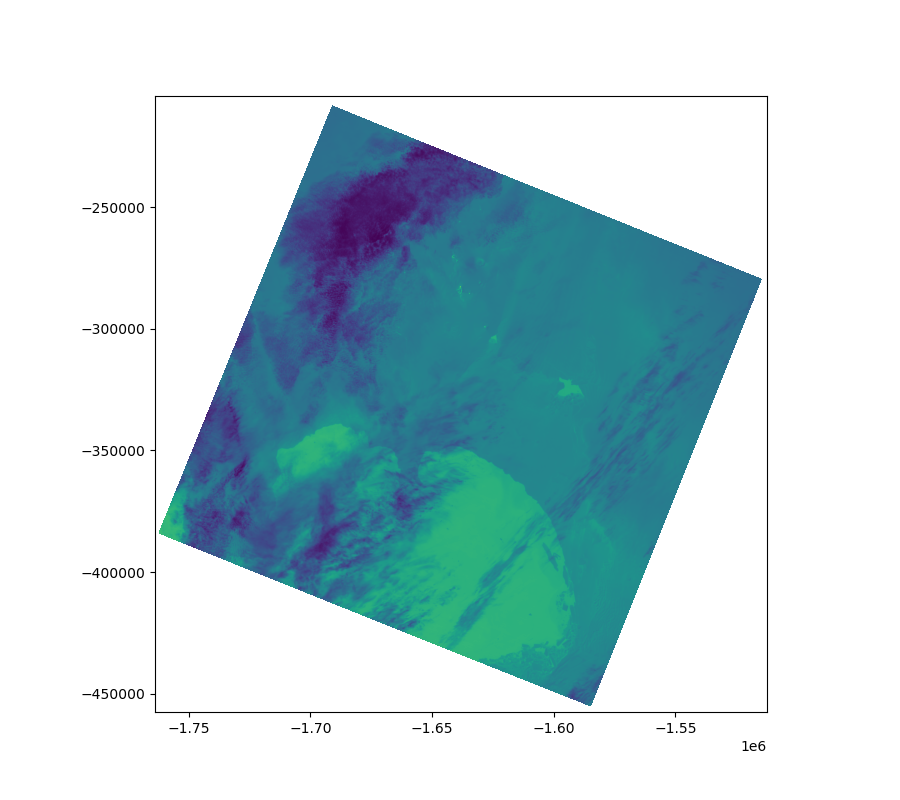

In [22]:
item0 = catalog[sceneids[0]]

# Retrieve first scene using rio
item_url = item0.lwir11.metadata['alternate']['s3']['href']

# Read and plot with grid coordinates 
with rio.Env(aws_session):
    with rio.open(item_url) as src:
        fig, ax = plt.subplots(figsize=(9,8))
        
        # To plot
        show(src,1)
        
        # To open data into a numpy array
        profile = src.profile
        arr = src.read(1)

## Read into Xarray

In [23]:
def landsat_to_xarray(sceneid, bandNames=None):
    """
    Function to ingest landsat scenes from AWS s3 bucket with alternate href.
    Args:
        catalog: an intake STAC item collection
        bandNames: a list of the bands you want e.g. ['red', 'swir16']
    Returns:
        Xarray of scenes with dimensions time, band, y, x
    """

    # Import to xarray with cloud mask
    # nans are in locations where concat of multiple scenes has expanded the grid
    item = catalog[sceneid.id]

    bands = []
    band_names = []

    if bandNames is None:
        # Get band names
        for k in item.keys():
            M = getattr(item, k).metadata
            if 'eo:bands' in M:
                resol = M['eo:bands'][0]['gsd']
                if resol >= 30: # thermal bands are up sampled from 100 to 30
                    band_names.append(k)
    else:
        band_names = bandNames

    # Add qa band
    if 'qa_pixel' not in band_names:
        band_names.append('qa_pixel')
    
    band_names.append('VZA')
    band_names.append('qa_radsat')

    # Construct xarray for scene
    for band_name in band_names:
        asset = sceneid.assets[band_name]
        href = asset.extra_fields['alternate']['s3']['href']

        band = xr.open_dataset(href, engine='rasterio', chunks=dict(band=1, x=512, y=512))
        band['band'] = [band_name]
        bands.append(band)
    ls_scene = xr.concat(bands, dim='band')
    ls_scene.coords['id'] = sceneid.id
    ls_scene.coords['time'] = item.metadata['datetime'].strftime('%Y-%m-%dT%H:%M:%S')
    ls_scene = ls_scene['band_data']

    return ls_scene

##########################

def create_masks(ls_scene, cloud_mask=True, ice_mask=False, ocean_mask=False):
    """
    Create cloud, ice, and ocean masks. cloud is 1, ice is 2, ocean is 3, everything else is NaN.
    Args:
        ls_scene: xarray of one LS scenes output from landsat_to_xarray
        cloud_mask: bool to generate cloud mask, default True
        ice_mask: bool to generate ice mask, default False
        ocean_mask: bool to generate ocean mask, default False
    Returns:
        new xarray of LS scene with mask
    """
    
    cloud = []
    ocean = []
    ice = []

    qa = ls_scene.sel(band='qa_pixel').astype('uint16')

    n,c = np.unique(qa, return_counts=True)

    for j in range(len(n)):
        longform = f'{n[j]:016b}'
        if (longform[-7]=='0')|(longform[-3]=='1'): #bit 2 and 6 are for cirrus and clear sky
            cloud.append(n[j])
        if longform[-8:]=='11000000': #bit 6 and 7 give clear sky and water, lower bits need to be 0 
            ocean.append(n[j])
        if longform[-7:]=='1100000': #bit 5 and 6 give ice and clear sky 
            ice.append(n[j])

    if 0 in cloud:
        cloud.remove(0)
    if 1 in cloud:
        cloud.remove(1)

    # mask cloud, ice, and ocean
    if cloud_mask==True:
        # cloud is 2
        mask_c = xr.where(qa.isin(cloud), 1, np.nan)

    if ice_mask==True:
        mask_c = xr.where(qa.isin(ice), 2, mask_c)

    if ocean_mask==True:
        mask_c = xr.where(qa.isin(ocean), 3, mask_c)

    ls_scene.coords['mask'] = (('y', 'x'), mask_c.data)
        
    return ls_scene

##########################

def search_stac(url,bbox,timeRange,collection,gjson_outfile):
    # Search STAC API for Landsat images based on a bounding box, date and other metadata if desired
    api = pystac_client.Client.open(url)

    items = api.search(
                bbox = bbox,
                datetime = timeRange,
                # limit = 400,
                collections=collection
            ).item_collection()

    print(f'{len(items)} items')

    # Write a json file that records our search output
    items.save_object(gjson_outfile)
    
    return items

##########################

def plot_search(gf,satellite,colnm):
    # Plot search AOI and frames on a map using Holoviz Libraries (more on these later)
    cols = gf.loc[:,('id',colnm[0],colnm[1],'geometry')]
    alpha = 1/gf.shape[0]**0.5 # transparency scales w number of images

    footprints = cols.hvplot(geo=True, line_color='k', hover_cols=[colnm[0],colnm[1]], alpha=alpha, title=satellite,tiles='ESRI')
    tiles = gv.tile_sources.CartoEco.options(width=700, height=500) 
    labels = gv.tile_sources.StamenLabels.options(level='annotation')
    tiles * footprints * labels
    
    return footprints

In [24]:
# Authenticate for boto S3 access, etc.
os.environ["AWS_REQUEST_PAYER"] = "requester"
aws_session = AWSSession(boto3.Session(), requester_pays=True)

In [25]:
# Setup and authenticate 
from dask.distributed import Client
import logging
client = Client(processes=True, n_workers=4, 
                threads_per_worker=1,
                silence_logs=logging.ERROR)
client.run(lambda: os.environ["AWS_REQUEST_PAYER"] == "requester" )
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/tsnow03/proxy/41951/status,
Dashboard: /user/tsnow03/proxy/41951/status,Workers: 4
Total threads: 4,Total memory: 29.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39451,Workers: 0
Dashboard: /user/tsnow03/proxy/41951/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46259,Total threads: 1
Dashboard: /user/tsnow03/proxy/44065/status,Memory: 7.42 GiB
Nanny: tcp://127.0.0.1:40069,


In [26]:
# Define the landsat STAC catalog location
url = 'https://landsatlook.usgs.gov/stac-server'

# For search and tile plot for Landsat
satellite = 'Landsat8'
collection = 'landsat-c2l1' # Landsat Collection 2, Level 1 - includes L8 and L9
colnm = ['landsat:wrs_path','landsat:wrs_row']
gjson_outfile = '/home/jovyan/Landsat_SST_algorithm/Data/{satellite}.geojson'

# timeRange = '2023-02-01/2023-02-01'

In [27]:
# Search for desired Landsat scenes
items = search_stac(url,bbox,dateRng,collection,gjson_outfile)

# Open stac catalog for some needed info
catalog = intake.open_stac_item_collection(items)

# Load the geojson file
gf = gpd.read_file(gjson_outfile)

Skipping field instruments: unsupported OGR type: 5
Skipping field proj:shape: unsupported OGR type: 1
Skipping field proj:transform: unsupported OGR type: 1


1 items


In [28]:
# Plot tiles of all scenes found
plot_search(gf,satellite,colnm)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (landsat:wrs_path,landsat:wrs_row)

In [29]:
sceneid = items[0]
print(sceneid.id)
    
scene = catalog[sceneid.id]
timestr = scene.metadata['datetime'].strftime('%H%M%S')

# Open all desired bands for one scene
ls_scene = landsat_to_xarray(sceneid)
ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)

# Create classification mask
ls_scene = create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)

# try:
# # Check for any open ocean pixels in bounding box - go to next image if none - 9.3 s
# mask = np.ones(ls_scene.shape[1:])
# mask[ls_scene.mask!=3] = np.nan
ls_thermal = ls_scene.sel(band=['blue','green','red','lwir11']).compute()
ls_box = subset_img(ls_thermal,polarx,polary) #ls_thermal*mask
ls_box

LC08_L1GT_001113_20230125_20230208_02_T2
(4, 1521, 1314)


<xarray.DataArray 'band_data' (band: 4, y: 1521, x: 1314)> Size: 32MB
array([[[24822., 24833., 24809., ..., 24032., 23258., 23963.],
        [24805., 24808., 24828., ..., 23777., 22836., 24714.],
        [24859., 24825., 24811., ..., 24108., 24339., 24867.],
        ...,
        [21028., 21435., 21606., ..., 25097., 25059., 24994.],
        [21199., 21563., 21685., ..., 25202., 25045., 25003.],
        [21292., 21543., 21559., ..., 25115., 25049., 25094.]],

       [[23296., 23269., 23239., ..., 21606., 21549., 21864.],
        [23231., 23225., 23261., ..., 21294., 21580., 22308.],
        [23296., 23230., 23215., ..., 22829., 21780., 23182.],
        ...,
        [19199., 19427., 19652., ..., 23798., 23722., 23650.],
        [19276., 19522., 19857., ..., 23921., 23711., 23639.],
        [19228., 19579., 19844., ..., 23819., 23727., 23764.]],

       [[23453., 23489., 23403., ..., 21146., 21567., 21243.],
        [23414., 23395., 23450., ..., 21892., 20659., 22039.],
        [23466., 23418., 23393., ..., 22198., 22028., 22389.],
        ...,
        [19020., 19314., 19575., ..., 24352., 24286., 24217.],
        [19046., 19416., 19786., ..., 24507., 24276., 24218.],
        [19119., 19516., 19730., ..., 24396., 24281., 24335.]],

       [[14863., 14860., 14850., ..., 14978., 14982., 14994.],
        [14859., 14855., 14844., ..., 15020., 15018., 15015.],
        [14852., 14850., 14840., ..., 15080., 15082., 15071.],
        ...,
        [14125., 14175., 14240., ..., 15069., 15048., 15036.],
        [14143., 14202., 14298., ..., 15066., 15044., 15026.],
        [14188., 14267., 14364., ..., 15083., 15064., 15045.]]],
      dtype=float32)
Coordinates:
  * band         (band) <U9 144B 'blue' 'green' 'red' 'lwir11'
  * x            (x) float64 11kB -1.626e+06 -1.626e+06 ... -1.586e+06
  * y            (y) float64 12kB -2.94e+05 -2.941e+05 ... -3.396e+05 -3.396e+05
    id           <U40 160B 'LC08_L1GT_001113_20230125_20230208_02_T2'
    time         <U19 76B '2023-01-25T14:52:12'
    spatial_ref  int64 8B 0
    mask         (y, x) float64 16MB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
Attributes:
    AREA_OR_POINT:  Point

## Subset one image

In [30]:
sbands = ['blue','green','red','lwir11']

# Select the first datetime
t = ls_box.time.values
print (t)

# Upper left and lower right coordinates for subsetting to Pine Island area
ulx = -1635000
uly = -290000
lrx = -1580000
lry = -350000

ds = ds19

timage = ls_box.sel(band='lwir11',y=slice(lry,uly),x=slice(ulx,lrx))
bimage = ls_box.sel(band='blue',y=slice(lry,uly),x=slice(ulx,lrx))

if (timage.x.shape[0]==0) & (timage.y.shape[0]==0):
    print ('L8 x and y shapes are 0')
    timage = ls_box.sel(band='lwir11',y=slice(uly,lry),x=slice(lrx,ulx))
    bimage = ls_box.sel(band='blue',y=slice(uly,lry),x=slice(lrx,ulx))
elif timage.y.shape[0]==0:
    print ('L8 y shape is 0')
    timage = ls_box.sel(band='lwir11',y=slice(uly,lry),x=slice(ulx,lrx))
    bimage = ls_box.sel(band='blue',y=slice(uly,lry),x=slice(ulx,lrx))
elif timage.x.shape[0]==0:
    print ('L8 x shape is 0')
    timage = ls_box.sel(band='lwir11',y=slice(lry,uly),x=slice(lrx,ulx))
    bimage = ls_box.sel(band='blue',y=slice(lry,uly),x=slice(lrx,ulx))
    
# image = image.rio.reproject(4326) ##doesn't work

pol_y = timage.y
pol_x = timage.x
pol_x, pol_y = np.meshgrid(pol_x, pol_y)

inProj = Proj(init='epsg:3031')
outProj = Proj(init='epsg:4326')
pol_lon,pol_lat = transform(inProj,outProj,pol_x,pol_y) # This order from the landsat coordinates to lat lon

timagen = np.array(timage.where(timage.notnull(),0))
# image = np.moveaxis(image, 0, -1)

2023-01-25T14:52:12
L8 y shape is 0


In [31]:
# Take transect of pixels used in the calculation
data = ds.where((ds.spot==1.0), drop=True)
t_transect,lat_transect,lon_transect = get_transect_v2(timagen,timage,pol_lon,pol_lat,data)
data = ds.where((ds.spot==2.0), drop=True)
t_transect2,lat_transect2,lon_transect2 = get_transect_v2(timagen,timage,pol_lon,pol_lat,data)
data = ds.where((ds.spot==3.0), drop=True)
t_transect3,lat_transect3,lon_transect3 = get_transect_v2(timagen,timage,pol_lon,pol_lat,data)
data = ds.where((ds.spot==4.0), drop=True)
t_transect4,lat_transect4,lon_transect4 = get_transect_v2(timagen,timage,pol_lon,pol_lat,data)
data = ds.where((ds.spot==5.0), drop=True)
t_transect5,lat_transect5,lon_transect5 = get_transect_v2(timagen,timage,pol_lon,pol_lat,data)
data = ds.where((ds.spot==6.0), drop=True)
t_transect6,lat_transect6,lon_transect6 = get_transect_v2(timagen,timage,pol_lon,pol_lat,data)

In [32]:
from matplotlib.colors import Normalize

class ThreeSlopeNorm(Normalize):
    def __init__(self, vmin, vmidlow, vcenter, vmax):
        super().__init__(vmin, vmax)
        self.vmin = vmin
        self.vmidlow = vmidlow
        self.vcenter = vcenter
        self.vmax = vmax

    def __call__(self, value, clip=None):
        # Normalize values piecewise into [0, 1]
        value = np.ma.masked_array(value)
        result = np.empty_like(value, dtype=float)

        # Segment 1: vmin → vmidlow
        mask1 = (value <= self.vmidlow)
        result[mask1] = 0.25 * (value[mask1] - self.vmin) / (self.vmidlow - self.vmin)

        # Segment 2: vmidlow → vcenter
        mask2 = (value > self.vmidlow) & (value <= self.vcenter)
        result[mask2] = 0.25 + 0.25 * (value[mask2] - self.vmidlow) / (self.vcenter - self.vmidlow)

        # Segment 3: vcenter → vmax
        mask3 = (value > self.vcenter)
        result[mask3] = 0.5 + 0.5 * (value[mask3] - self.vcenter) / (self.vmax - self.vcenter)

        return result


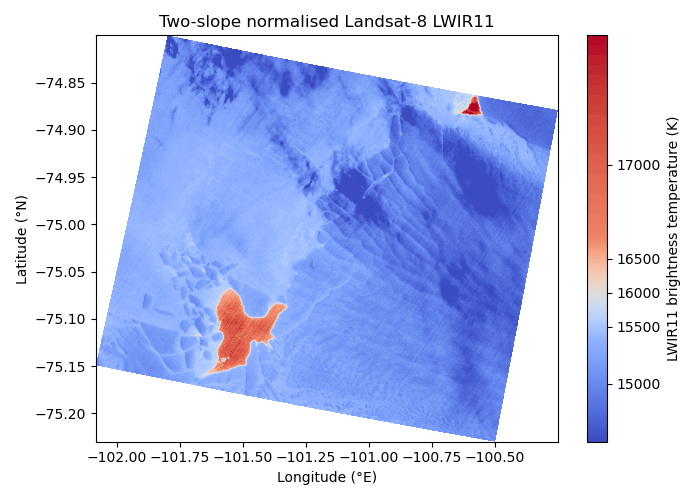

In [33]:
from matplotlib.colors import TwoSlopeNorm

# norm = TwoSlopeNorm(vmin=14000, vmax=17350, vcenter=16800) # used with coolwarm cmap
# cmap = "coolwarm"
norm = ThreeSlopeNorm(vmin=14600, vmidlow=15300, vcenter=16800, vmax=17350) # used with cmocean thermal
cmap = 'coolwarm'

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    pol_lon, pol_lat, timagen.squeeze(),      # timagen is (y, x) after meshgrid
    cmap=cmap,                          # any diverging map you like
    norm=norm,
    shading='auto'
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('LWIR11 brightness temperature (K)')

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('Two-slope normalised Landsat-8 LWIR11')

plt.tight_layout()
plt.show()

## Plot Landsat thermal

In [34]:
hxlim = [[-75.15,-75.07],
        [-75.17,-74.98],
         [-75.16,-75.02], 
         [-75.16,-75.02], #?
         [-75.1,-74.98],
         [-75.1,-74.98],
       ]
        
hylim = [[-0.6,-0.3],
        [-0.8,-0.3], #[-28.55,-28.3],[-28.57,-28.1], old values
         [-1,0.0],
         [-0.8,0.1],#?
         [-0.9,-0.1],
         [-0.9,-0.1],
       ]

thermylim = [[16350,17550],
             [14000, 16590], 
             [11900, 17200],
             [11900, 17200], #?
             [16000,17500],
             [16000,17500],
            ]

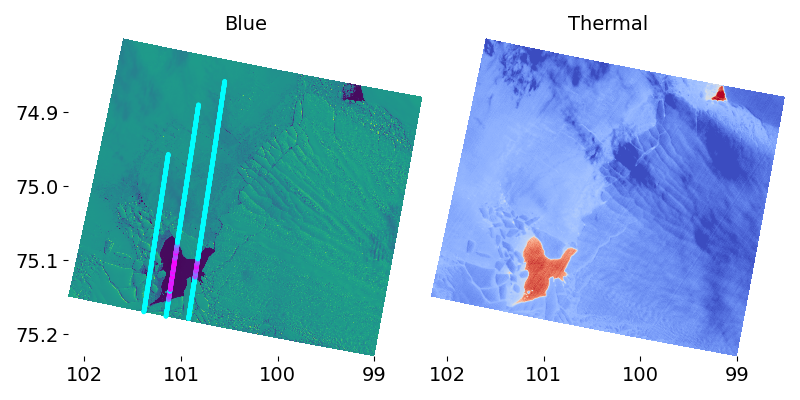

In [35]:
# spot [?,3,1,1,5]
fig, (ax,ax1) = plt.subplots(ncols=2,sharey=True,sharex=True,figsize=(8,4))
data1 = ds.where(ds['spot']==1)
data2 = ds.where(ds['spot']==2)
data3 = ds.where(ds['spot']==3)
data4 = ds.where(ds['spot']==4)
data5 = ds.where(ds['spot']==5)
data6 = ds.where(ds['spot']==6)

tmax,tmin = 17250,17000
bmax,bmin = 26500,17000

ax.tick_params(labelsize=14)
ax.pcolormesh(pol_lon,pol_lat,bimage) #,vmin=bmin,vmax=bmax
# # ax.plot(dataset['lon_ph'],dataset['lat_ph'],color='r',linewidth=1)
# dataC = ax.scatter(lon_transect,lat_transect,c=t_transect,s=5,cmap='cool',zorder=2,vmin=tmin,vmax=tmax) #thermal # could be t_transect or mask_transect
ax.scatter(lon_transect2,lat_transect2,c=t_transect2,s=5,cmap='cool',zorder=2,vmin=tmin,vmax=tmax) #thermal
# ax.scatter(lon_transect3,lat_transect3,c=t_transect3,s=5,cmap='cividis',zorder=2,vmin=tmin,vmax=tmax) #thermal
ax.scatter(lon_transect4,lat_transect4,c=t_transect4,s=5,cmap='cool',zorder=2,vmin=tmin,vmax=tmax) #thermal
# ax.scatter(lon_transect5,lat_transect5,c=t_transect5,s=5,cmap='cool',zorder=2,vmin=tmin,vmax=tmax) #thermal
ax.scatter(lon_transect6,lat_transect6,c=t_transect6,s=5,cmap='cool',zorder=2,vmin=tmin,vmax=tmax) #thermal
# # fig.colorbar(data1, ax=ax)
ax.set_title('Blue', fontsize=14)

ax1.tick_params(labelsize=14)
# ax1.pcolormesh(pol_lon,pol_lat,timagen,vmin=tmin,vmax=tmax)
pcm = ax1.pcolormesh(
    pol_lon, pol_lat, timagen.squeeze(),      # timagen is (y, x) after meshgrid
    cmap='coolwarm',                          # cmocean.cm.thermal
    norm=norm,
    shading='auto'
)
# # data = ax1.scatter(lon_transect,lat_transect,c=t_transect,s=5,cmap='Grays',zorder=2,vmin=tmin,vmax=tmax)
# # data = ax1.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap='Purples',vmin=-28.6,vmax=-28)
# # data1 = ax1.scatter(data['longitude'],data['latitude'],c=data['h_mean'],s=5,cmap='Oranges',vmin=-0.8,vmax=0.1)
# dataS = ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=4,cmap='Oranges',vmin=hylim[0][0],vmax=hylim[0][1])
# ax1.scatter(data2['longitude'],data2['latitude'],c=data2['h_mean'],s=4,cmap='Oranges',vmin=hylim[1][0],vmax=hylim[1][1])
# ax1.scatter(data3['longitude'],data3['latitude'],c=data3['h_mean'],s=4,cmap='Oranges',vmin=hylim[2][0],vmax=hylim[2][1])
# ax1.scatter(data4['longitude'],data4['latitude'],c=data4['h_mean'],s=4,cmap='Oranges',vmin=hylim[3][0],vmax=hylim[3][1])
# ax1.scatter(data5['longitude'],data5['latitude'],c=data5['h_mean'],s=4,cmap='Oranges',vmin=hylim[4][0],vmax=hylim[4][1])
# ax1.scatter(data6['longitude'],data6['latitude'],c=data6['h_mean'],s=4,cmap='Oranges',vmin=hylim[5][0],vmax=hylim[5][1])
ax1.set_title('Thermal', fontsize=14)
ax1.axes.get_yaxis().set_visible(False)
xticks = ax1.get_xticks()
xticklabels = [str(abs(int(tick))) for tick in xticks]
xticklabels = np.array([103, 102, 101, 100,99])
ax.set_xticklabels(xticklabels)
yticks = ax.get_yticks()
yticklabels = [str(abs(np.around(tick,1))) for tick in yticks]
ax.set_yticklabels(yticklabels)
for position in ['left', 'right', 'bottom', 'top']:
    ax.spines[position].set_visible(False)
    ax1.spines[position].set_visible(False)
# cbar = fig.colorbar(dataS, ax=ax1,label='Sea Surface Height')
# cbar.set_label('Sea Surface Height', size=14, rotation=270, labelpad=20)
# cbar.ax.tick_params(labelsize=14)

plt.tight_layout(w_pad=0.2)

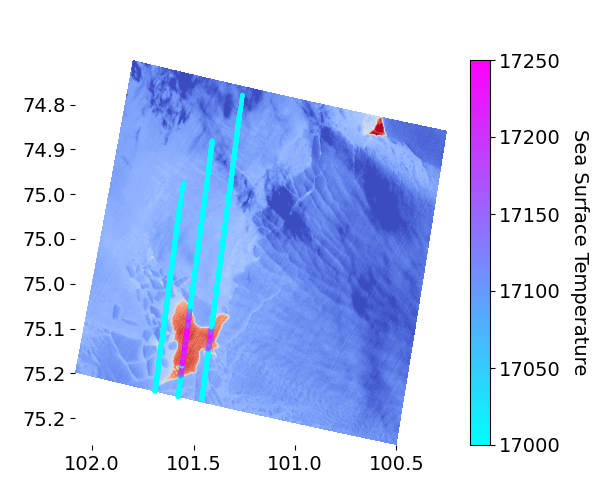

In [36]:
fig, ax = plt.subplots(figsize=(6,5))

# tmax,tmin = 17400,17200 #0
# tmax,tmin = 16300,13500 #1
tmax,tmin = 17250,17000 #4
pmax,pmin = 17800,12000 #4

cmap = 'cool'

data1 = ds.where(ds['spot']==1)
data2 = ds.where(ds['spot']==2)
data3 = ds.where(ds['spot']==3)
data4 = ds.where(ds['spot']==4)
data5 = ds.where(ds['spot']==5)
data6 = ds.where(ds['spot']==6)

ax.tick_params(labelsize=14)
ax.pcolormesh(pol_lon,pol_lat,timagen,vmin=tmin,vmax=tmax) #
pcm = ax.pcolormesh(
    pol_lon, pol_lat, timagen.squeeze(),      # timagen is (y, x) after meshgrid
    cmap='coolwarm',                          # cmocean.cm.thermal
    norm=norm,
    shading='auto'
)
# # To show elevation from in house processing
# ssh = ssh_dset_dict['gt1l']
# data = ax.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# ssh = ssh_dset_dict['gt1r']
# ax.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# ssh = ssh_dset_dict['gt2l']
# ax.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# ssh = ssh_dset_dict['gt2r']
# ax.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# ssh = ssh_dset_dict['gt3l']
# ax.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# ssh = ssh_dset_dict['gt3r']
# ax.scatter(ssh['lon'],ssh['lat'],c=ssh['h_estimate'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# # To show elevation from SlideRule
# data1 = ds.where((ds.spot==1.0), drop=True)
# data = ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# data1 = ds.where((ds.spot==2.0), drop=True)
# ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# data1 = ds.where((ds.spot==3.0), drop=True)
# ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# data1 = ds.where((ds.spot==4.0), drop=True)
# ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# data1 = ds.where((ds.spot==5.0), drop=True)
# ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)
# data1 = ds.where((ds.spot==6.0), drop=True)
# ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_mean'],s=5,cmap=cmap,vmin=tmin,vmax=tmax)

# To show thermal
data = ax.scatter(lon_transect,lat_transect,c=t_transect,s=4,cmap=cmap,zorder=2,vmin=tmin,vmax=tmax)
ax.scatter(lon_transect2,lat_transect2,c=t_transect2,s=4,cmap=cmap,zorder=2,vmin=tmin,vmax=tmax)
ax.scatter(lon_transect3,lat_transect3,c=t_transect3,s=4,cmap=cmap,zorder=2,vmin=tmin,vmax=tmax)
ax.scatter(lon_transect4,lat_transect4,c=t_transect4,s=4,cmap=cmap,zorder=2,vmin=tmin,vmax=tmax)
ax.scatter(lon_transect5,lat_transect5,c=t_transect5,s=4,cmap=cmap,zorder=2,vmin=tmin,vmax=tmax)
ax.scatter(lon_transect6,lat_transect6,c=t_transect6,s=4,cmap=cmap,zorder=2,vmin=tmin,vmax=tmax)

# # To show SSH
# data1 = ax.scatter(data1['longitude'],data1['latitude'],c=data1['h_corr'],s=4,cmap='Oranges',vmin=hylim[z][0],vmax=hylim[z][1])
# ax.scatter(data2['longitude'],data2['latitude'],c=data2['h_corr'],s=4,cmap='Oranges',vmin=hylim[z][0],vmax=hylim[z][1])
# ax.scatter(data3['longitude'],data3['latitude'],c=data3['h_corr'],s=4,cmap='Oranges',vmin=hylim[z][0],vmax=hylim[z][1])
# ax.scatter(data4['longitude'],data4['latitude'],c=data4['h_corr'],s=4,cmap='Oranges',vmin=hylim[z][0],vmax=hylim[z][1])
# ax.scatter(data5['longitude'],data5['latitude'],c=data5['h_corr'],s=4,cmap='Oranges',vmin=hylim[z][0],vmax=hylim[z][1])
# ax.scatter(data6['longitude'],data6['latitude'],c=data6['h_corr'],s=4,cmap='Oranges',vmin=hylim[z][0],vmax=hylim[z][1])

# ax.title.set_text('Thermal')
xticks = ax.get_xticks()
xticklabels = [str(abs(tick)) for tick in xticks]
ax.set_xticklabels(xticklabels)
yticks = ax.get_yticks()
yticklabels = [str(abs(np.around(tick,1))) for tick in yticks]
ax.set_yticklabels(yticklabels)
for position in ['left', 'right', 'bottom', 'top']:
    ax.spines[position].set_visible(False)
    
cbar = fig.colorbar(data, ax=ax,label='Thermal') # (data1, ax=ax,label='Sea Surface Height')
cbar.set_label('Sea Surface Temperature', size=14, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=14)

## IS2 transects and corrections

In [38]:
# Setup and authenticate 
from dask.distributed import Client
import logging
client = Client(processes=True, n_workers=4, 
                threads_per_worker=1,
                silence_logs=logging.ERROR)
client.run(lambda: os.environ["AWS_REQUEST_PAYER"] == "requester" )
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/tsnow03/proxy/36183/status,
Dashboard: /user/tsnow03/proxy/36183/status,Workers: 4
Total threads: 4,Total memory: 29.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38079,Workers: 0
Dashboard: /user/tsnow03/proxy/36183/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45449,Total threads: 1
Dashboard: /user/tsnow03/proxy/38507/status,Memory: 7.42 GiB
Nanny: tcp://127.0.0.1:45647,


In [39]:
ds19 = xr.open_dataset('/home/jovyan/Data/2019IS2trans.nc')
ds21 = xr.open_dataset('/home/jovyan/Data/2021IS2trans.nc')

In [43]:
ds

<xarray.Dataset> Size: 760kB
Dimensions:                 (delta_time: 5588)
Coordinates:
  * delta_time              (delta_time) datetime64[ns] 45kB 2019-01-15T05:24...
    latitude                (delta_time) float64 45kB ...
    longitude               (delta_time) float64 45kB ...
Data variables: (12/14)
    cycle                   (delta_time) float64 45kB ...
    distance                (delta_time) float64 45kB ...
    segment_id              (delta_time) float64 45kB ...
    gt                      (delta_time) float64 45kB ...
    h_sigma                 (delta_time) float64 45kB ...
    h_mean                  (delta_time) float64 45kB ...
    ...                      ...
    dh_fit_dy               (delta_time) float64 45kB ...
    rms_misfit              (delta_time) float64 45kB ...
    spot                    (delta_time) float64 45kB 1.0 1.0 1.0 ... 6.0 6.0
    dh_fit_dx               (delta_time) float64 45kB ...
    pflags                  (delta_time) float64 45kB ...
    rgt                     (delta_time) float64 45kB ...
Attributes: (12/21)
    featureType:           trajectory
    title:                 ATLAS/ICESat-2 SlideRule Height
    reference:             https://doi.org/10.5281/zenodo.5484048
    date_created:          2022-10-24T08:13:24.901817
    date_type:             UTC
    time_type:             CCSDS UTC-A
    ...                    ...
    res:                   10.0
    yapc:                  {"score": 192, "knn": 0, "min_ph": 4, "win_h": 3, ...
    version:               1.4.6
    commit:                v1.4.6-0-g300fc61
    poly0_x:               [-100.3773, -101.081, -102.2457, -101.1967, -100.3...
    poly0_y:               [-74.844, -74.7785, -75.1702, -75.1829, -74.844]

1
2
3
4
5
6
CPU times: user 200 ms, sys: 21.5 ms, total: 221 ms
Wall time: 196 ms


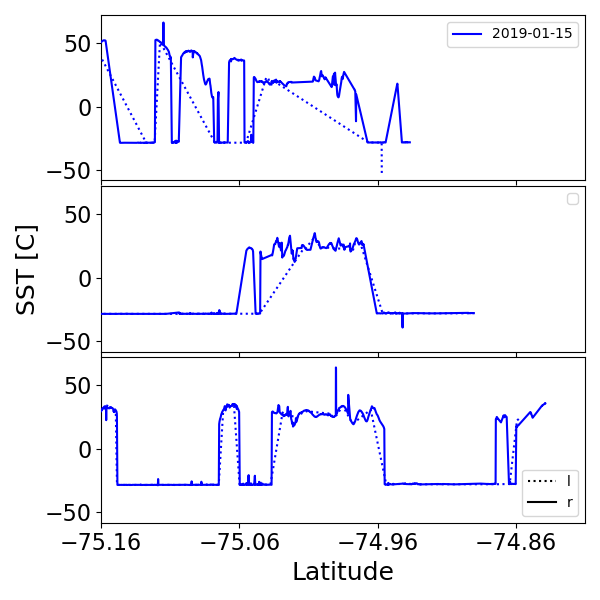

In [52]:
%%time

# Prints out all figures with no transparency per transect
hxlim = [-75.16,-74.81]
hylim = [-28.55,-28.1] #[-28.55,-28.3],[-28.57,-28.1]

# Get the winter colormap, Extract the desired number of colors
cmap = plt.cm.winter
num_files = len(allfiles)
colors = cmap(np.linspace(0, 1, num_files))
ds = ds19

data1 = ds.where(ds['spot'] == 1).dropna(dim='delta_time', how='all')
data2 = ds.where(ds['spot']==2).dropna(dim='delta_time', how='all')
data3 = ds.where(ds['spot']==3).dropna(dim='delta_time', how='all')
data4 = ds.where(ds['spot']==4).dropna(dim='delta_time', how='all')
data5 = ds.where(ds['spot']==5).dropna(dim='delta_time', how='all')
data6 = ds.where(ds['spot']==6).dropna(dim='delta_time', how='all')

fig, axs = plt.subplots(ncols=1,nrows=3,sharey=True,sharex=True,figsize=(6,6))

i=0

# Add to plot
ax = axs[2]
ax.tick_params(labelsize=16)
if np.isnan(np.nanmax(data1['h_mean']))==0:
    ax.plot(data1['latitude'],data1['h_mean'],color=colors[i],zorder=zorder[i])
    print(1)
if np.isnan(np.nanmax(data2['h_mean']))==0:
    ax.plot(data2['latitude'],data2['h_mean'],color=colors[i],linestyle=':',zorder=zorder[i])
    print(2)
if i == 0:
    ax.plot([-75,-75],[0,0],linestyle=':',color='k',label='l') #SR
    ax.plot([-75,-75],[0,0],linestyle='-',color='k',label='r') #SR
    ax.legend(loc='lower right',fontsize=10)
ax.set_xlim(hxlim);
ax.set_xticks(np.arange(hxlim[0],hxlim[1],0.1))
# ax.set_ylim(hylim);
ax.set_xlabel('Latitude',fontsize=18)  

ax = axs[1]
ax.tick_params(labelsize=16)
if np.isnan(np.nanmax(data3['h_mean']))==0:
    ax.plot(data3['latitude'],data3['h_mean'],color=colors[i],zorder=zorder[i])#label='Thermal')
    print(3)
if np.isnan(np.nanmax(data4['h_mean']))==0:
    ax.plot(data4['latitude'],data4['h_mean'],color=colors[i],linestyle=':',zorder=zorder[i])
    print(4)
if i > 5:
    ax.plot([-75,-75],[0,0],linestyle='-',color=colors[i],label=f'{str(ds.delta_time[0].values)[:10]}')
# ax.set_xlim(sxlim[z]);
# ax.set_xticks(np.arange(sxlim[z][0],sxlim[z][1],0.05))
# ax.set_ylim(hylim);
ax.legend(loc='upper right',fontsize=10) 
ax.set_ylabel('SST [C]',fontsize=18)

ax = axs[0]
ax.tick_params(labelsize=16)
if np.isnan(np.nanmax(data5['h_mean']))==0:
    ax.plot(data5['latitude'],data5['h_mean'],color=colors[i],zorder=zorder[i])
    print(5)
if np.isnan(np.nanmax(data6['h_mean']))==0:
    ax.plot(data6['latitude'],data6['h_mean'],color=colors[i],linestyle=':',zorder=zorder[i])
    print(6)
if i < 6:
    ax.plot([-75,-75],[0,0],linestyle='-',color=colors[i],label=f'{str(ds.delta_time[0].values)[:10]}')
# ax.set_ylim(hylim);
ax.legend(loc='upper right',fontsize=10)  

plt.tight_layout(h_pad=0.02)
frame_path = f"/home/jovyan/Landsat_SST_algorithm/Figures/SSH_frame_{i:03d}.png"
# plt.savefig(frame_path, dpi=200)  # PNG preferred over JPG for lossless GIFs
# plt.show()

In [ ]:
from netCDF4 import Dataset
from scipy.interpolate import RegularGridInterpolator
from scipy.io import loadmat

In [53]:
ds

<xarray.Dataset> Size: 760kB
Dimensions:                 (delta_time: 5588)
Coordinates:
  * delta_time              (delta_time) datetime64[ns] 45kB 2019-01-15T05:24...
    latitude                (delta_time) float64 45kB ...
    longitude               (delta_time) float64 45kB ...
Data variables: (12/14)
    cycle                   (delta_time) float64 45kB ...
    distance                (delta_time) float64 45kB ...
    segment_id              (delta_time) float64 45kB ...
    gt                      (delta_time) float64 45kB ...
    h_sigma                 (delta_time) float64 45kB ...
    h_mean                  (delta_time) float64 45kB ...
    ...                      ...
    dh_fit_dy               (delta_time) float64 45kB ...
    rms_misfit              (delta_time) float64 45kB ...
    spot                    (delta_time) float64 45kB 1.0 1.0 1.0 ... 6.0 6.0
    dh_fit_dx               (delta_time) float64 45kB ...
    pflags                  (delta_time) float64 45kB ...
    rgt                     (delta_time) float64 45kB ...
Attributes: (12/21)
    featureType:           trajectory
    title:                 ATLAS/ICESat-2 SlideRule Height
    reference:             https://doi.org/10.5281/zenodo.5484048
    date_created:          2022-10-24T08:13:24.901817
    date_type:             UTC
    time_type:             CCSDS UTC-A
    ...                    ...
    res:                   10.0
    yapc:                  {"score": 192, "knn": 0, "min_ph": 4, "win_h": 3, ...
    version:               1.4.6
    commit:                v1.4.6-0-g300fc61
    poly0_x:               [-100.3773, -101.081, -102.2457, -101.1967, -100.3...
    poly0_y:               [-74.844, -74.7785, -75.1702, -75.1829, -74.844]

In [50]:

# Function to pad a string
def pad_string(number, length=4, pad_char='0'):
    return str(number).rjust(length, pad_char)

# Replace 'testrgt' and the paths with actual values
testrgt = 20
src = f'/home/jovyan/Data/2019IS2trans.nc'

# Read data from the netCDF file
with Dataset(src, 'r') as nc:
    lat_yp = nc.variables['latitude'][:]
    lon_yp = nc.variables['longitude'][:]
    hmn_yp = nc.variables['h_mean'][:]

# Load geoid data
geoid_data = loadmat('path_to_your_mat_file/EGM2008_Antarctic.mat')

# Adjust longitude
lon_yp[lon_yp < 0] += 360

# Interpolation for geoid
EGM2008_lon = geoid_data['EGM2008']['lon'][0][0][0]
EGM2008_lat = geoid_data['EGM2008']['lat'][0][0][0]
EGM2008_geoid = geoid_data['EGM2008']['geoid'][0][0]

# Check the shape of the geoid data
print("Shape of EGM2008_geoid:", EGM2008_geoid.shape)

# Assuming EGM2008_geoid is a 2D array of shape (len(EGM2008_lat), len(EGM2008_lon))
interpolator = RegularGridInterpolator((EGM2008_lat, EGM2008_lon), EGM2008_geoid, method='linear', bounds_error=False, fill_value=None)
lon_lat_yp = np.vstack((lon_yp, lat_yp)).T
geoid_yp = interpolator(lon_lat_yp)

# Correct SR height with just Geoid
H_cor = hmn_yp - geoid_yp


'2019-01-15'